# Week 5 Dataset Creation: Behavioral Momentum Disruptors

Instructor notebook. Generates `behavioral_momentum_extinction_data.csv` and `behavioral_momentum_alternative_data.csv` by simulating Nevin's resistance-to-change equations (extinction and alternative-reinforcement disruptors) with added noise.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit

# Set random seed for reproducibility
np.random.seed(73125)

## Behavioral Momentum for Extinction

Generated Dataset:
     condition  session  response_rate         r         c         d  \
0  Condition_1        0      47.313090  7.029639  0.033241  0.027086   
1  Condition_1        1      34.044050  7.029639  0.033241  0.027086   
2  Condition_1        2      30.206973  7.029639  0.033241  0.027086   
3  Condition_1        3      21.808532  7.029639  0.033241  0.027086   
4  Condition_1        4      16.817207  7.029639  0.033241  0.027086   
5  Condition_1        5      12.097423  7.029639  0.033241  0.027086   
6  Condition_1        6      17.024100  7.029639  0.033241  0.027086   
7  Condition_1        7      14.928618  7.029639  0.033241  0.027086   
8  Condition_1        8       8.819348  7.029639  0.033241  0.027086   
9  Condition_1        9       8.762949  7.029639  0.033241  0.027086   

          B0  
0  44.903574  
1  44.903574  
2  44.903574  
3  44.903574  
4  44.903574  
5  44.903574  
6  44.903574  
7  44.903574  
8  44.903574  
9  44.903574  

Parameter Values for E

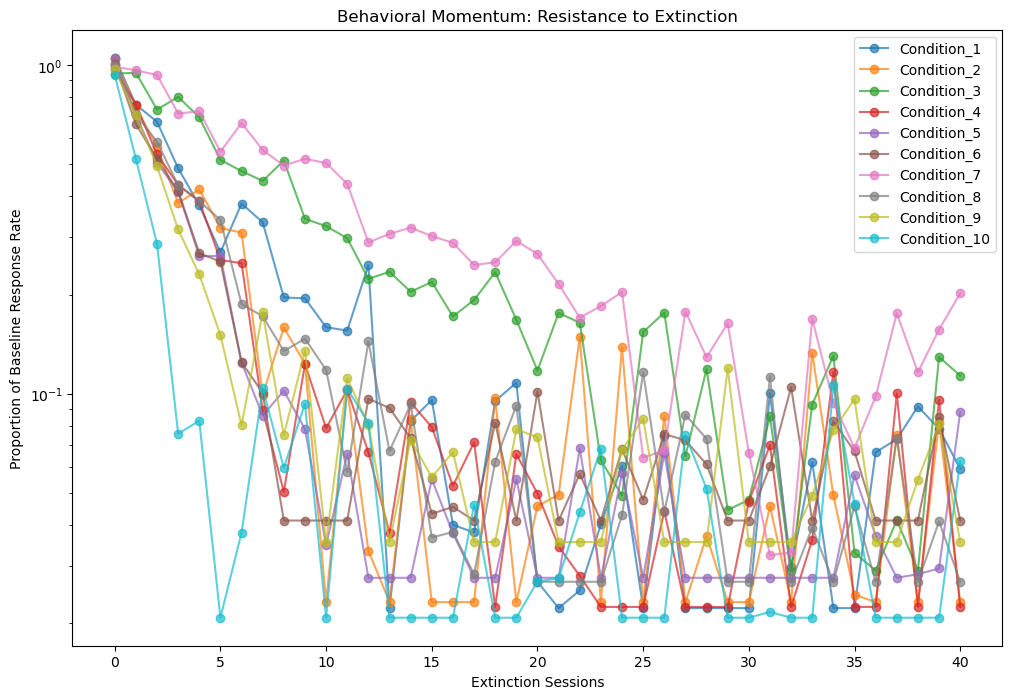

In [ ]:
# Define the behavioral momentum equation for resistance to extinction
def behavioral_momentum_extinction(t, c, d, r, B0):
    """
    B_t / B_o = 10^((-t * (c + d * r)) / r^0.5)
    
    Parameters:
    t: time/sessions of extinction
    c: scaling parameter for suspending contingency
    d: scaling parameter for removing reinforcers
    r: reinforcement rate
    B0: baseline response rate
    """
    exponent = (-t * (c + d * r)) / (r ** 0.5)
    ratio = 10 ** exponent
    return B0 * ratio

# Generate parameters for different experimental conditions
conditions = []
for i in range(10):  # 5 different experimental conditions
    # Vary reinforcement rates
    r = np.random.uniform(0.5, 10)
    
    # Vary contingency parameters
    c = np.random.uniform(0.001, 0.1)
    d = np.random.uniform(0.001, 0.1)
    
    # Vary baseline response rates
    B0 = np.random.uniform(20, 60)
    
    conditions.append({
        'condition': f'Condition_{i+1}',
        'r': r,
        'c': c,
        'd': d,
        'B0': B0
    })

# Generate time points (extinction sessions)
t_max = 40
t = np.arange(0, t_max + 1)

# Generate data for each condition
data = []
for condition in conditions:
    # Generate theoretical values
    B_t = behavioral_momentum_extinction(t, condition['c'], condition['d'], 
                                       condition['r'], condition['B0'])
    
    # Add some noise to make it more realistic
    noise = np.random.normal(0, 0.05 * condition['B0'], len(t))
    B_t_noisy = B_t + noise
    
    # Ensure no negative values
    B_t_noisy = np.maximum(B_t_noisy, 0)
    
    # Create data rows
    for i, (time_point, response_rate) in enumerate(zip(t, B_t_noisy)):
        data.append({
            'condition': condition['condition'],
            'session': time_point,
            'response_rate': response_rate+1,
            'r': condition['r'],
            'c': condition['c'],
            'd': condition['d'],
            'B0': condition['B0']+1
        })

# Create DataFrame
df = pd.DataFrame(data)

# Display the first few rows
print("Generated Dataset:")
print(df.head(10))

# Display parameter values for each condition
print("\nParameter Values for Each Condition:")
for condition in conditions:
    print(f"{condition['condition']}: r={condition['r']:.3f}, c={condition['c']:.3f}, "
          f"d={condition['d']:.3f}, B0={condition['B0']:.1f}")

# Plot the data
plt.figure(figsize=(12, 8))
for condition_name in df['condition'].unique():
    condition_data = df[df['condition'] == condition_name]
    plt.plot(condition_data['session'], condition_data['response_rate']/condition_data['B0'], 
             marker='o', label=condition_name, alpha=0.7)

plt.xlabel('Extinction Sessions', fontsize=20, labelpad=12)
plt.ylabel('Proportion of Baseline Response Rate', fontsize=20, labelpad=12)
plt.yscale('log')
plt.title('Behavioral Momentum: Resistance to Extinction')
plt.legend()
plt.show()

# Save to CSV
df.to_csv('behavioral_momentum_extinction_data.csv', index=False)

## Behavioral Momentum for Alternative Reinforcement

Generated Dataset:
     condition   Ra  response_rate         r         p         B0
0  Condition_1  0.0      49.135658  6.617426  0.655511  53.505239
1  Condition_1  0.1      46.885119  6.617426  0.655511  53.505239
2  Condition_1  0.2      46.752154  6.617426  0.655511  53.505239
3  Condition_1  0.3      45.348074  6.617426  0.655511  53.505239
4  Condition_1  0.4      44.162903  6.617426  0.655511  53.505239
5  Condition_1  0.5      41.925594  6.617426  0.655511  53.505239
6  Condition_1  0.6      39.707499  6.617426  0.655511  53.505239
7  Condition_1  0.7      37.941524  6.617426  0.655511  53.505239
8  Condition_1  0.8      36.693510  6.617426  0.655511  53.505239
9  Condition_1  0.9      29.818904  6.617426  0.655511  53.505239

Parameter Values for Each Condition:
Condition_1: r=6.617, p=0.656, B0=52.5
Condition_2: r=2.389, p=0.469, B0=52.1
Condition_3: r=5.097, p=1.367, B0=65.5
Condition_4: r=8.640, p=0.627, B0=79.7
Condition_5: r=7.317, p=1.084, B0=51.8
Condition_6: r=5.966, 

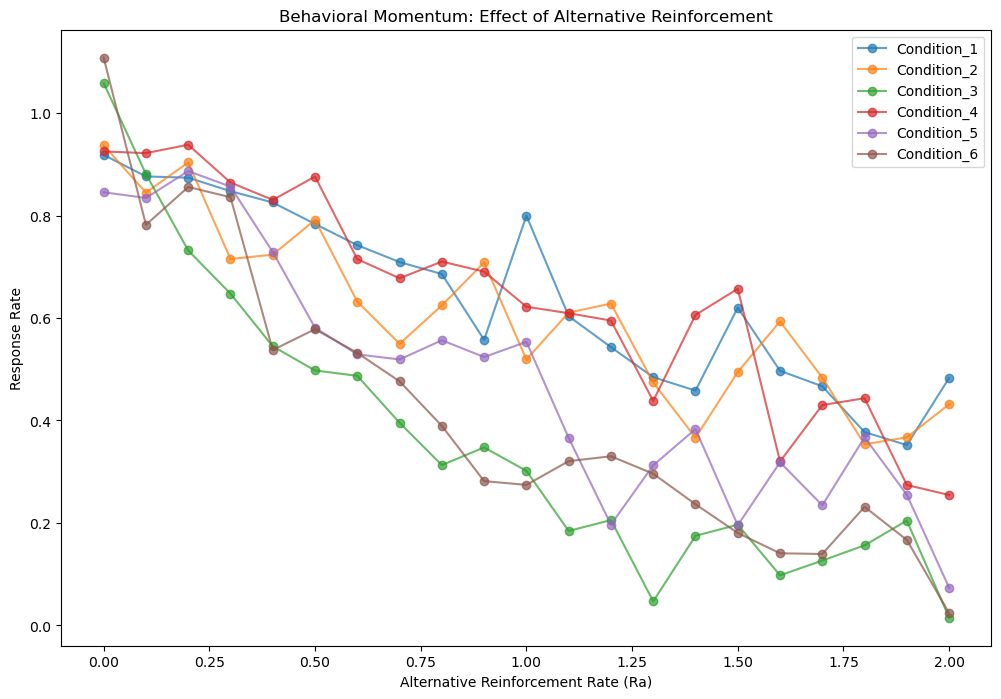

In [ ]:
# Define the behavioral momentum equation for alternative reinforcement
def behavioral_momentum_alternative(B0, p, r, Ra):
    """
    B_x / B_o = 10^((-p * R_a) / (r + R_a)^0.5)
    
    Parameters:
    B0: baseline response rate
    p: parameter scaling the effect of alternative reinforcement
    r: baseline reinforcement rate
    Ra: alternative reinforcement rate
    """
    # Calculate the ratio
    exponent = (-p * Ra) / ((r + Ra) ** 0.5)
    ratio = 10 ** exponent
    
    # Calculate the new response rate
    Bx = B0 * ratio
    return Bx

# Generate parameters for different experimental conditions
conditions = []
for i in range(6):  # 6 different experimental conditions
    # Vary baseline reinforcement rates
    r = np.random.uniform(0.5, 10)
    
    # Vary alternative reinforcement rates
    Ra = np.random.uniform(1, 20)
    
    # Vary the scaling parameter
    p = np.random.uniform(0.1, 2)
    
    # Vary baseline response rates
    B0 = np.random.uniform(30, 80)
    
    conditions.append({
        'condition': f'Condition_{i+1}',
        'r': r,
        'Ra': Ra,
        'p': p,
        'B0': B0
    })

# Generate alternative reinforcement rates for testing
Ra_values = np.linspace(0, 2.0, 21)  # 0 to 2.0 in 21 steps

# Generate data for each condition
data = []
for condition in conditions:
    # Generate theoretical values for different Ra levels
    B_x = behavioral_momentum_alternative(condition['B0'], condition['p'], 
                                        condition['r'], Ra_values)
    
    # Add some noise to make it more realistic
    noise = np.random.normal(0, 0.08 * condition['B0'], len(Ra_values))
    B_x_noisy = B_x + noise
    
    # Ensure no negative values
    B_x_noisy = np.maximum(B_x_noisy, 0)
    
    # Create data rows
    for i, (Ra_level, response_rate) in enumerate(zip(Ra_values, B_x_noisy)):
        data.append({
            'condition': condition['condition'],
            'Ra': Ra_level,
            'response_rate': response_rate+1,
            'r': condition['r'],
            'p': condition['p'],
            'B0': condition['B0']+1
        })

# Create DataFrame
df = pd.DataFrame(data)

# Display the first few rows
print("Generated Dataset:")
print(df.head(10))

# Display parameter values for each condition
print("\nParameter Values for Each Condition:")
for condition in conditions:
    print(f"{condition['condition']}: r={condition['r']:.3f}, p={condition['p']:.3f}, "
          f"B0={condition['B0']:.1f}")

# Plot the data
plt.figure(figsize=(12, 8))
for condition_name in df['condition'].unique():
    condition_data = df[df['condition'] == condition_name]
    plt.plot(condition_data['Ra'], condition_data['response_rate']/condition_data['B0'], 
             marker='o', label=condition_name, alpha=0.7)

plt.xlabel('Alternative Reinforcement Rate (Ra)', fontsize=20, labelpad=12)
plt.ylabel('Proportion of Baseline Response Rate', fontsize=20, labelpad=12)
plt.title('Behavioral Momentum: Effect of Alternative Reinforcement')
plt.legend()
plt.show()

# Save to CSV
df.to_csv('behavioral_momentum_alternative_data.csv', index=False)